In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure



Image loaded successfully.


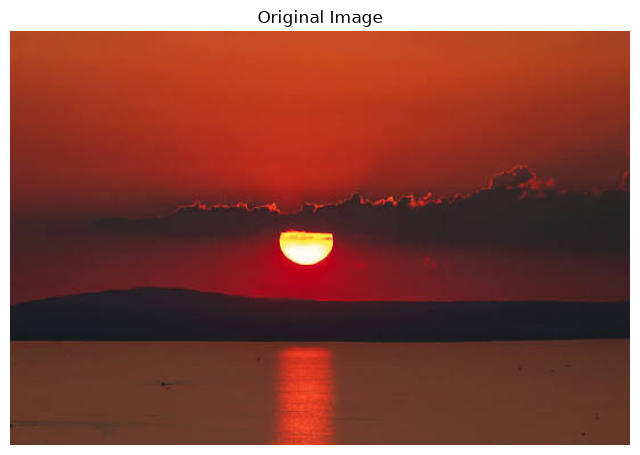

In [7]:
image_path = "images.jpeg"

image = cv2.imread(image_path)

# Check whether image is loaded
if image is None:
    print("Error: Image not found!")
else:
    print("Image loaded successfully.")

# OpenCV reads images in BGR format
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


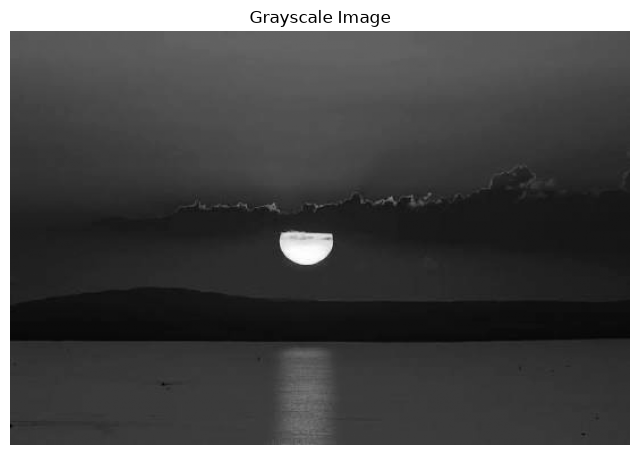

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


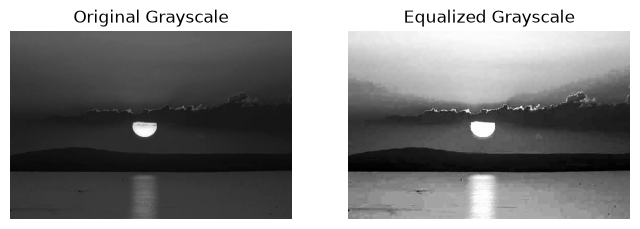

In [9]:
gray_equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(8, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray_equalized, cmap='gray')
plt.title("Equalized Grayscale")
plt.axis("off")

plt.show()


In [10]:
# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and calculate descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Number of keypoints detected:", len(keypoints))
print("Descriptor shape:", descriptors.shape)


Number of keypoints detected: 32
Descriptor shape: (32, 128)


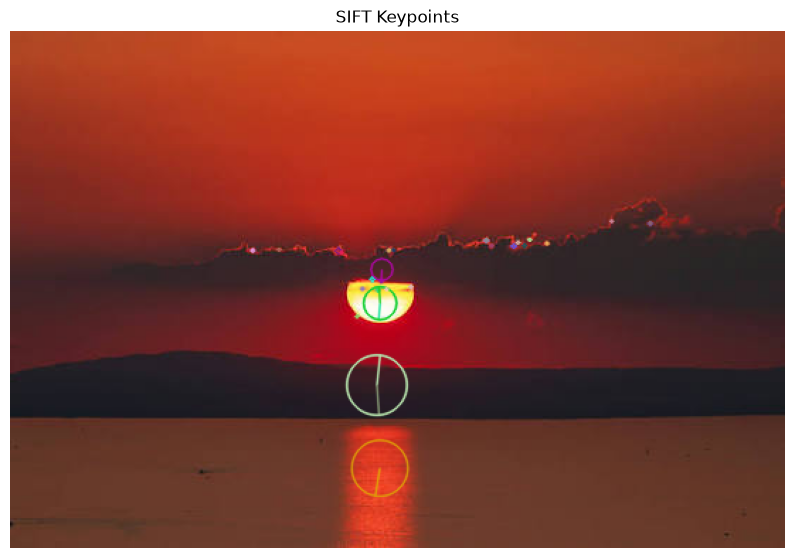

In [11]:
sift_image = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(10, 8))
plt.imshow(sift_image)
plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()


In [12]:
for i, kp in enumerate(keypoints[:10]):
    print(
        f"Keypoint {i+1}: "
        f"x={kp.pt[0]:.2f}, "
        f"y={kp.pt[1]:.2f}, "
        f"size={kp.size:.2f}, "
        f"angle={kp.angle:.2f}"
    )


Keypoint 1: x=170.86, y=154.55, size=2.25, angle=285.17
Keypoint 2: x=189.44, y=153.98, size=2.14, angle=275.78
Keypoint 3: x=231.35, y=154.73, size=4.63, angle=290.24
Keypoint 4: x=233.49, y=156.15, size=1.98, angle=269.99
Keypoint 5: x=244.50, y=201.15, size=2.07, angle=309.49
Keypoint 6: x=248.30, y=181.53, size=1.87, angle=95.47
Keypoint 7: x=255.32, y=174.82, size=3.31, angle=96.03
Keypoint 8: x=258.52, y=249.59, size=42.39, angle=85.89
Keypoint 9: x=258.52, y=249.59, size=42.39, angle=276.12
Keypoint 10: x=259.17, y=182.42, size=2.21, angle=87.73


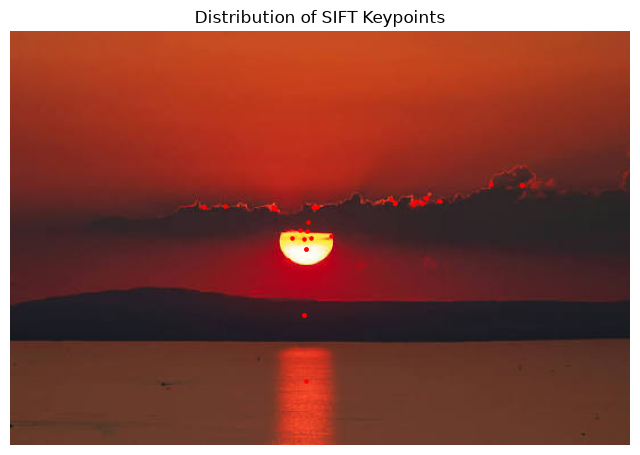

In [13]:
x_coords = [kp.pt[0] for kp in keypoints]
y_coords = [kp.pt[1] for kp in keypoints]

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.scatter(x_coords, y_coords, s=5, c='red')
plt.title("Distribution of SIFT Keypoints")
plt.axis("off")
plt.show()


In [14]:
gray_float = gray.astype(np.float32) / 255.0

features, hog_image = hog(
    gray_float,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    visualize=True
)

print("HOG feature vector length:", len(features))


HOG feature vector length: 106128


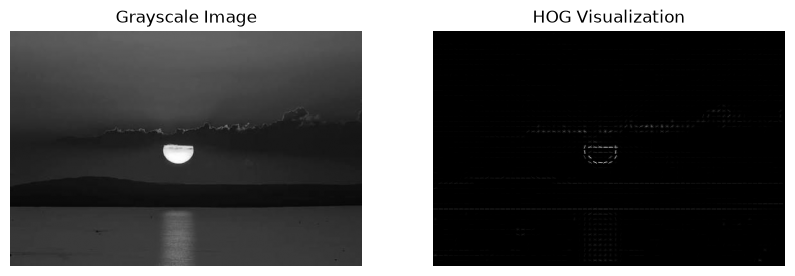

In [15]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Visualization")
plt.axis("off")

plt.show()


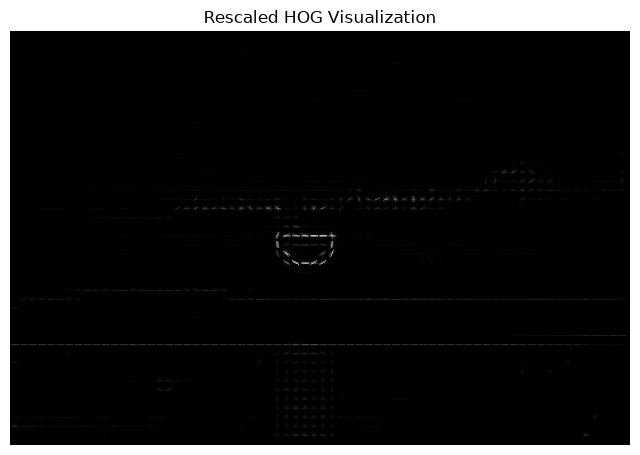

In [16]:
hog_image_rescaled = exposure.rescale_intensity(
    hog_image,
    in_range=(0, 10)
)

plt.figure(figsize=(8, 6))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("Rescaled HOG Visualization")
plt.axis("off")
plt.show()


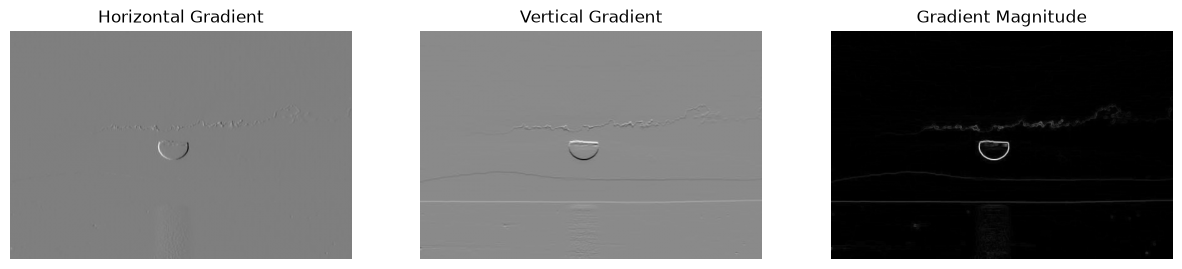

In [17]:
gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

magnitude = cv2.magnitude(
    gx.astype(np.float32),
    gy.astype(np.float32)
)

angle = cv2.phase(
    gx.astype(np.float32),
    gy.astype(np.float32),
    angleInDegrees=True
)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(gx, cmap='gray')
plt.title("Horizontal Gradient")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gy, cmap='gray')
plt.title("Vertical Gradient")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.show()


In [18]:
print("Number of SIFT keypoints:", len(keypoints))
print("SIFT descriptor dimensions:", descriptors.shape)

print("HOG feature vector dimensions:", features.shape)


Number of SIFT keypoints: 32
SIFT descriptor dimensions: (32, 128)
HOG feature vector dimensions: (106128,)


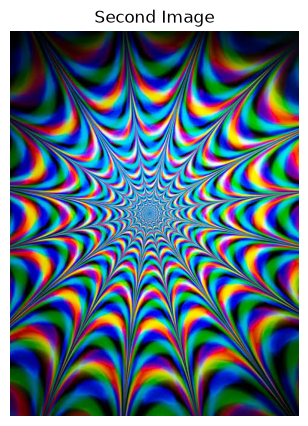

In [20]:
image2 = cv2.imread("colourful.jpeg")

if image2 is None:
    print("Second image not found!")
else:
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 5))
    plt.imshow(image2_rgb)
    plt.title("Second Image")
    plt.axis("off")
    plt.show()


In [21]:
kp1, des1 = sift.detectAndCompute(gray, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("Image 1 keypoints:", len(kp1))
print("Image 2 keypoints:", len(kp2))


Image 1 keypoints: 32
Image 2 keypoints: 1464


In [22]:
bf = cv2.BFMatcher(cv2.NORM_L2)

matches = bf.knnMatch(des1, des2, k=2)

print("Number of initial matches:", len(matches))


Number of initial matches: 32


In [23]:
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))



Good matches: 0


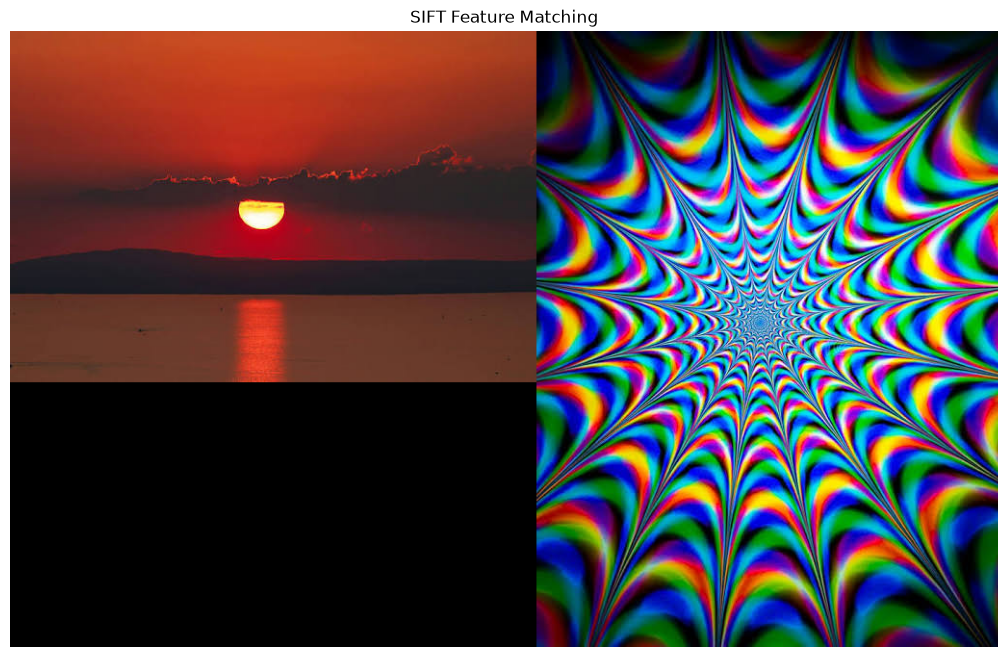

In [24]:
match_image = cv2.drawMatches(
    image_rgb,
    kp1,
    image2_rgb,
    kp2,
    good_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15, 8))
plt.imshow(match_image)
plt.title("SIFT Feature Matching")
plt.axis("off")
plt.show()
